# Photography Location Recommender System ด้วย Neo4j

นำข้อมูลจาก `664245006_PhotograhyLocation_RecommenderSystem.ipynb` มาใช้ใน Neo4j: ผู้ใช้ 10 คน สถานที่ถ่ายรูป 10 แห่ง และความชอบ 21 รายการ ระบบแนะนำสถานที่จากผู้ใช้ที่มีความชอบคล้ายกัน


## 1. เชื่อมต่อ Neo4j Aura

ใส่ URI และชื่อผู้ใช้ของฐานข้อมูลตัวเอง แล้วป้อนรหัสผ่านเมื่อโปรแกรมถาม


In [31]:
!pip install -q neo4j networkx matplotlib pandas


In [32]:
import neo4j
from getpass import getpass
from neo4j import GraphDatabase
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("Neo4j Python Driver Version:", neo4j.__version__)


Neo4j Python Driver Version: 6.3.1


In [33]:
URI = "neo4j+s://b2073959.databases.neo4j.io"
USERNAME = "b2073959"
PASSWORD = getpass("Password: ")

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))
driver.verify_connectivity()
print("Connected successfully")


Password: ··········
Connected successfully


หา home database


In [34]:
result = driver.execute_query("SHOW HOME DATABASE")
for record in result.records:
    print(record.data())


{'name': 'b2073959', 'type': 'standard', 'aliases': [], 'access': 'read-write', 'address': 'p-mt-2e58c6e6c448-26-0137.production-orch-0703.neo4j.io:7687', 'role': 'primary', 'writer': True, 'requestedStatus': 'online', 'currentStatus': 'online', 'statusMessage': '', 'constituents': []}


เก็บชื่อ database


In [35]:
DATABASE = result.records[0]["name"]
print("Database =", DATABASE)


Database = b2073959


ทดสอบใช้งานฐานข้อมูลจริง


In [36]:
result = driver.execute_query(
    "RETURN 'Hello Neo4j' AS message",
    database_=DATABASE
)
print(result.records[0]["message"])


Hello Neo4j


In [37]:
result = driver.execute_query(
    "MATCH (n) RETURN count(n) AS total_nodes",
    database_=DATABASE
)
print("จำนวน Node =", result.records[0]["total_nodes"])


จำนวน Node = 20


2. สร้าง Node User และ Photography Location


In [38]:
users = [
    "Pim", "Beam", "Mew", "Film", "Nina",
    "Earth", "Praew", "Win", "View", "Mark"
]

locations = [
    "ICONSIAM", "Talad Noi", "Asiatique The Riverfront",
    "Benjakitti Park", "Chatuchak Weekend Market", "The Commons Thonglor",
    "Wat Arun", "Yaowarat", "Bangkok Art and Culture Centre", "Ancient City"
]


In [39]:
driver.execute_query(
    "UNWIND $names AS name MERGE (:User {name: name})",
    names=users, database_=DATABASE
)
driver.execute_query(
    "UNWIND $names AS name MERGE (:Location {name: name})",
    names=locations, database_=DATABASE
)
print("สร้าง User และ Location เรียบร้อย")


สร้าง User และ Location เรียบร้อย


ตรวจสอบผลลัพธ์


In [40]:
result = driver.execute_query(
    "MATCH (n) WHERE n:User OR n:Location RETURN labels(n) AS type, properties(n) AS data",
    database_=DATABASE
)
for record in result.records:
    print(record.data())


{'type': ['User'], 'data': {'name': 'Pim'}}
{'type': ['User'], 'data': {'name': 'Beam'}}
{'type': ['User'], 'data': {'name': 'Mew'}}
{'type': ['User'], 'data': {'name': 'Film'}}
{'type': ['User'], 'data': {'name': 'Nina'}}
{'type': ['User'], 'data': {'name': 'Earth'}}
{'type': ['User'], 'data': {'name': 'Praew'}}
{'type': ['User'], 'data': {'name': 'Win'}}
{'type': ['User'], 'data': {'name': 'View'}}
{'type': ['User'], 'data': {'name': 'Mark'}}
{'type': ['Location'], 'data': {'name': 'ICONSIAM'}}
{'type': ['Location'], 'data': {'name': 'Talad Noi'}}
{'type': ['Location'], 'data': {'name': 'Asiatique The Riverfront'}}
{'type': ['Location'], 'data': {'name': 'Benjakitti Park'}}
{'type': ['Location'], 'data': {'name': 'Chatuchak Weekend Market'}}
{'type': ['Location'], 'data': {'name': 'The Commons Thonglor'}}
{'type': ['Location'], 'data': {'name': 'Wat Arun'}}
{'type': ['Location'], 'data': {'name': 'Yaowarat'}}
{'type': ['Location'], 'data': {'name': 'Bangkok Art and Culture Centre'}}


3. สร้าง Constraint


In [41]:
driver.execute_query(
    "CREATE CONSTRAINT user_name_unique IF NOT EXISTS FOR (u:User) REQUIRE u.name IS UNIQUE",
    database_=DATABASE
)
driver.execute_query(
    "CREATE CONSTRAINT location_name_unique IF NOT EXISTS FOR (l:Location) REQUIRE l.name IS UNIQUE",
    database_=DATABASE
)
print("สร้าง Constraint สำเร็จ")


สร้าง Constraint สำเร็จ


4. สร้างความสัมพันธ์ LIKES


In [42]:
likes = [
    ("Pim", "ICONSIAM"), ("Pim", "Talad Noi"),
    ("Beam", "ICONSIAM"), ("Beam", "Talad Noi"), ("Beam", "Yaowarat"),
    ("Mew", "Talad Noi"), ("Mew", "Bangkok Art and Culture Centre"),
    ("Film", "Yaowarat"), ("Film", "Chatuchak Weekend Market"),
    ("Nina", "Benjakitti Park"), ("Nina", "The Commons Thonglor"),
    ("Earth", "Benjakitti Park"), ("Earth", "The Commons Thonglor"), ("Earth", "Asiatique The Riverfront"),
    ("Praew", "Wat Arun"), ("Praew", "ICONSIAM"),
    ("Win", "Wat Arun"), ("Win", "Yaowarat"),
    ("View", "Chatuchak Weekend Market"), ("View", "Ancient City"),
    ("Mark", "Ancient City"), ("Mark", "Asiatique The Riverfront")
]


In [43]:
likes_data = [{"user": u, "location": l} for u, l in likes]

driver.execute_query(
    "UNWIND $rows AS row MATCH (u:User {name: row.user}), (l:Location {name: row.location}) MERGE (u)-[:LIKES]->(l)",
    rows=likes_data, database_=DATABASE
)
print("สร้างความสัมพันธ์ LIKES เรียบร้อย")


สร้างความสัมพันธ์ LIKES เรียบร้อย


ตรวจสอบจำนวนข้อมูล


In [44]:
result = driver.execute_query(
    "MATCH (u:User) OPTIONAL MATCH (u)-[r:LIKES]->(l:Location) "
    "RETURN count(DISTINCT u) AS users, count(DISTINCT l) AS locations, count(r) AS likes",
    database_=DATABASE
)
r = result.records[0]
print("Users:", r["users"])
print("Locations:", r["locations"])
print("LIKES:", r["likes"])


Users: 10
Locations: 10
LIKES: 22


5. เพิ่มความสัมพันธ์ User กับ User


ใช้ความสัมพันธ์ FRIEND เพื่อแสดงว่า User มีความสนใจ/รู้จักกัน และนำไปใช้วิเคราะห์เครือข่าย User


In [45]:
friendships = [
    ("Pim", "Beam"),
    ("Pim", "Mew"),
    ("Beam", "Mew"),
    ("Beam", "Film"),
    ("Mew", "Nina"),
    ("Film", "Win"),
    ("Nina", "Earth"),
    ("Earth", "Praew"),
    ("Praew", "Win"),
    ("Win", "View"),
    ("View", "Mark"),
    ("Mark", "Pim")
]

friend_data = [{"user1": u1, "user2": u2} for u1, u2 in friendships]

driver.execute_query(
    """
    UNWIND $rows AS row
    MATCH (u1:User {name: row.user1})
    MATCH (u2:User {name: row.user2})
    MERGE (u1)-[:FRIEND]-(u2)
    """,
    rows=friend_data,
    database_=DATABASE
)

print("สร้างความสัมพันธ์ User กับ User เรียบร้อย")


สร้างความสัมพันธ์ User กับ User เรียบร้อย


ตรวจสอบความสัมพันธ์ User กับ User


In [46]:
result = driver.execute_query(
    """
    MATCH (u1:User)-[:FRIEND]-(u2:User)
    RETURN u1.name AS user1, u2.name AS user2
    ORDER BY user1, user2
    """,
    database_=DATABASE
)

for r in result.records:
    print(f"{r['user1']} ↔ {r['user2']}")


Beam ↔ Film
Beam ↔ Mew
Beam ↔ Pim
Earth ↔ Nina
Earth ↔ Praew
Film ↔ Beam
Film ↔ Win
Mark ↔ Pim
Mark ↔ View
Mew ↔ Beam
Mew ↔ Nina
Mew ↔ Pim
Nina ↔ Earth
Nina ↔ Mew
Pim ↔ Beam
Pim ↔ Mark
Pim ↔ Mew
Praew ↔ Earth
Praew ↔ Win
View ↔ Mark
View ↔ Win
Win ↔ Film
Win ↔ Praew
Win ↔ View


6. กราฟแยก: User ชอบอะไร


กราฟนี้แสดงเฉพาะ User → Location ผ่านความสัมพันธ์ LIKES เพื่อให้เห็นว่าแต่ละ User ชอบสถานที่ใด


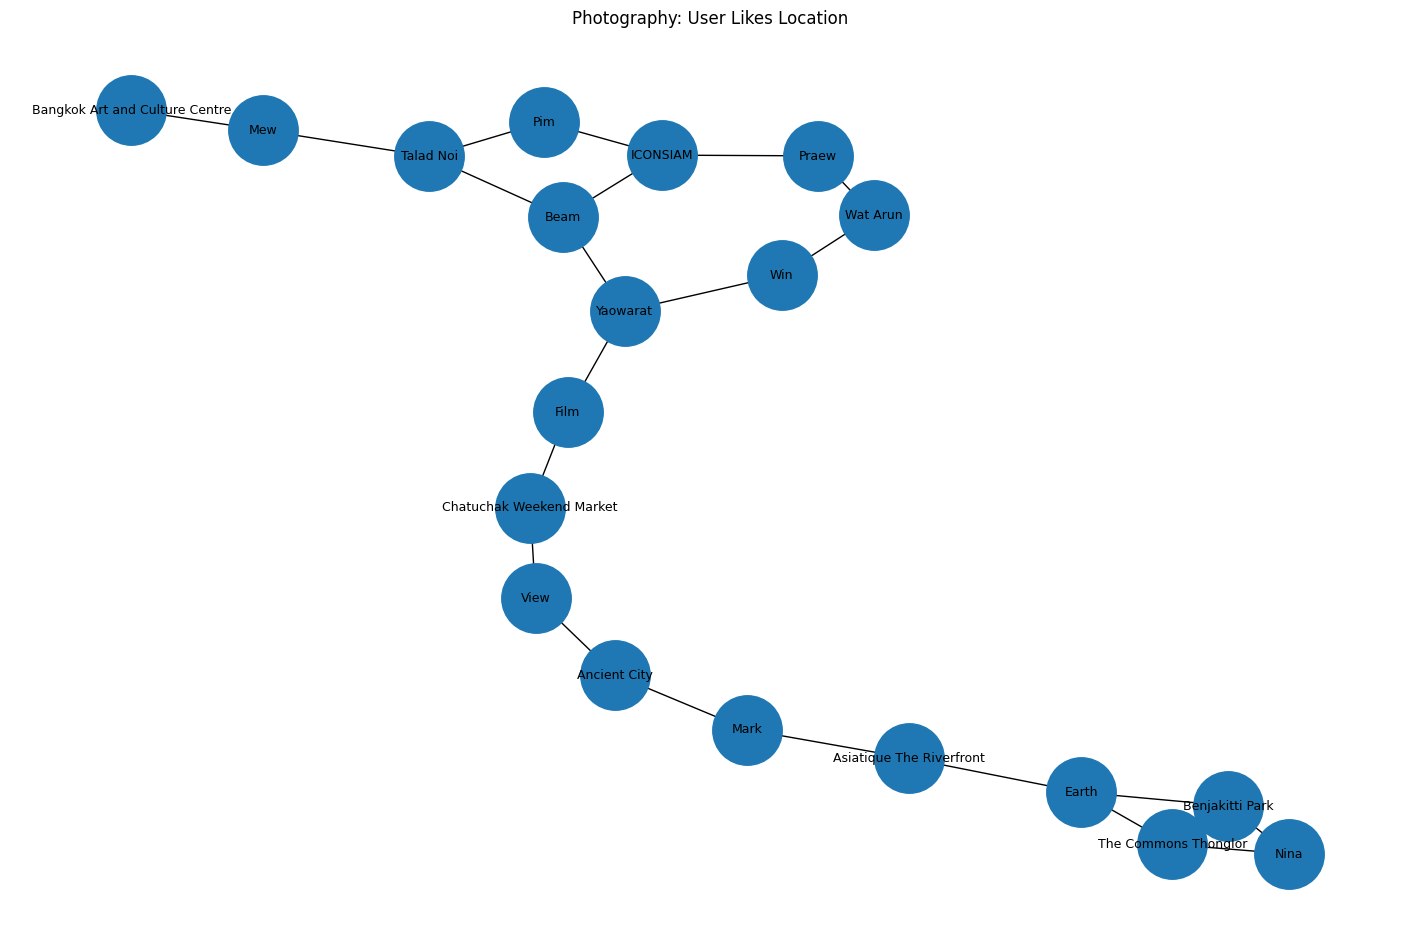

In [47]:
# ดึงข้อมูล User และ Location ที่มีความสัมพันธ์ LIKES จาก Neo4j
result = driver.execute_query(
    """
    MATCH (u:User)-[:LIKES]->(l:Location)
    RETURN u.name AS user, l.name AS location
    ORDER BY user, location
    """,
    # ระบุ Database ที่ต้องการใช้งาน
    database_=DATABASE
)


# สร้าง Graph สำหรับเก็บข้อมูล User และ Location
G_likes = nx.Graph()


# วนลูปอ่านข้อมูลที่ได้จาก Neo4j
for row in result.records:

    # เก็บชื่อ User
    user = row["user"]

    # เก็บชื่อ Location
    location = row["location"]

    # เพิ่ม User เป็น Node ในกราฟ
    G_likes.add_node(user, node_type="user")

    # เพิ่ม Location เป็น Node ในกราฟ
    G_likes.add_node(location, node_type="location")

    # สร้างเส้นเชื่อมระหว่าง User กับ Location
    # แสดงว่า User ชอบ Location นั้น
    G_likes.add_edge(user, location)


# กำหนดขนาดของพื้นที่สำหรับแสดงกราฟ
plt.figure(figsize=(14, 9))


# จัดตำแหน่งของ Node ในกราฟ
# seed=42 ทำให้ตำแหน่งกราฟเหมือนเดิมทุกครั้งที่รัน
pos = nx.spring_layout(G_likes, seed=42)


# วาดกราฟ User และ Location
nx.draw(

    # ใช้ข้อมูลจาก Graph ที่สร้างไว้
    G_likes,

    # ใช้ตำแหน่งของ Node ที่กำหนดไว้
    pos,

    # แสดงชื่อของ Node
    with_labels=True,

    # กำหนดขนาดของ Node
    node_size=2500,

    # กำหนดขนาดตัวอักษร
    font_size=9
)


# กำหนดชื่อกราฟ
plt.title("Photography: User Likes Location")

# แสดงกราฟ
plt.show()

7. กราฟแยก: User กับ User


กราฟนี้แสดงเฉพาะความสัมพันธ์ FRIEND ระหว่าง User กับ User


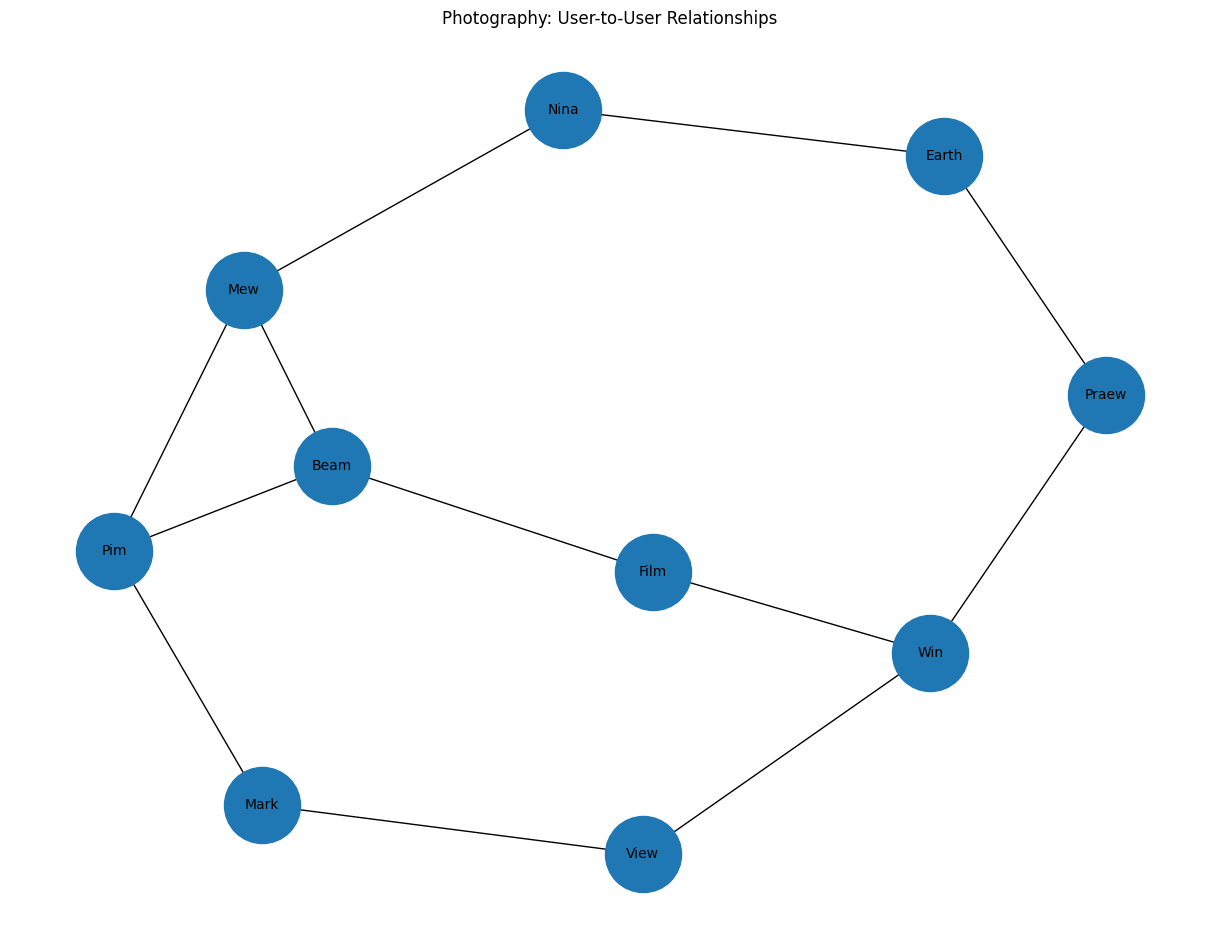

In [48]:
result = driver.execute_query(
    """
    MATCH (u1:User)-[:FRIEND]-(u2:User)
    RETURN DISTINCT u1.name AS user1, u2.name AS user2
    ORDER BY user1, user2
    """,
    database_=DATABASE
)

G_users = nx.Graph()

for row in result.records:
    G_users.add_edge(row["user1"], row["user2"])

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G_users, seed=42)
nx.draw(
    G_users,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10
)
plt.title("Photography: User-to-User Relationships")
plt.show()


8. Query User → เพื่อน → สถานที่ที่เพื่อนชอบ


In [49]:
result = driver.execute_query(
    """
    MATCH (u:User)-[:FRIEND]-(friend:User)-[:LIKES]->(l:Location)
    WHERE NOT (u)-[:LIKES]->(l)
    RETURN u.name AS user,
           friend.name AS friend,
           l.name AS location
    ORDER BY user, friend, location
    """,
    database_=DATABASE
)

for r in result.records:
    print(f"{r['user']} → เพื่อน {r['friend']} → ชอบ {r['location']}")


Beam → เพื่อน Film → ชอบ Chatuchak Weekend Market
Beam → เพื่อน Mew → ชอบ Bangkok Art and Culture Centre
Earth → เพื่อน Praew → ชอบ ICONSIAM
Earth → เพื่อน Praew → ชอบ Wat Arun
Film → เพื่อน Beam → ชอบ ICONSIAM
Film → เพื่อน Beam → ชอบ Talad Noi
Film → เพื่อน Win → ชอบ Wat Arun
Mark → เพื่อน Pim → ชอบ ICONSIAM
Mark → เพื่อน Pim → ชอบ Talad Noi
Mark → เพื่อน View → ชอบ Chatuchak Weekend Market
Mew → เพื่อน Beam → ชอบ ICONSIAM
Mew → เพื่อน Beam → ชอบ Yaowarat
Mew → เพื่อน Nina → ชอบ Benjakitti Park
Mew → เพื่อน Nina → ชอบ The Commons Thonglor
Mew → เพื่อน Pim → ชอบ ICONSIAM
Nina → เพื่อน Earth → ชอบ Asiatique The Riverfront
Nina → เพื่อน Mew → ชอบ Bangkok Art and Culture Centre
Nina → เพื่อน Mew → ชอบ Talad Noi
Pim → เพื่อน Beam → ชอบ Yaowarat
Pim → เพื่อน Mark → ชอบ Ancient City
Pim → เพื่อน Mark → ชอบ Asiatique The Riverfront
Pim → เพื่อน Mew → ชอบ Bangkok Art and Culture Centre
Praew → เพื่อน Earth → ชอบ Asiatique The Riverfront
Praew → เพื่อน Earth → ชอบ Benjakitti Park
Praew → เพื่อ

9. ทดลอง WHERE



In [50]:
result = driver.execute_query(
    "MATCH (u:User) WHERE u.name = 'Pim' RETURN u.name AS name",
    database_=DATABASE
)
for record in result.records:
    print(record.data())


{'name': 'Pim'}


10. Query ความสัมพันธ์ — สถานที่ที่ Pim ชอบ



In [51]:
result = driver.execute_query(
    "MATCH (:User {name: $name})-[:LIKES]->(l:Location) "
    "RETURN l.name AS location ORDER BY location",
    name="Pim", database_=DATABASE
)
print("สถานที่ที่ Pim ชอบ:", [r["location"] for r in result.records])


สถานที่ที่ Pim ชอบ: ['ICONSIAM', 'Talad Noi']


11. Query ผู้ใช้ที่มีความชอบร่วมกับ Pim



In [52]:
result = driver.execute_query(
    "MATCH (:User {name: $name})-[:LIKES]->(l:Location)<-[:LIKES]-(other:User) "
    "WHERE other.name <> $name "
    "RETURN l.name AS location, collect(other.name) AS similar_users ORDER BY location",
    name="Pim", database_=DATABASE
)
for r in result.records:
    print(r["location"], "->", r["similar_users"])


ICONSIAM -> ['Beam', 'Praew']
Talad Noi -> ['Beam', 'Mew']


12. วาดกราฟความชอบ



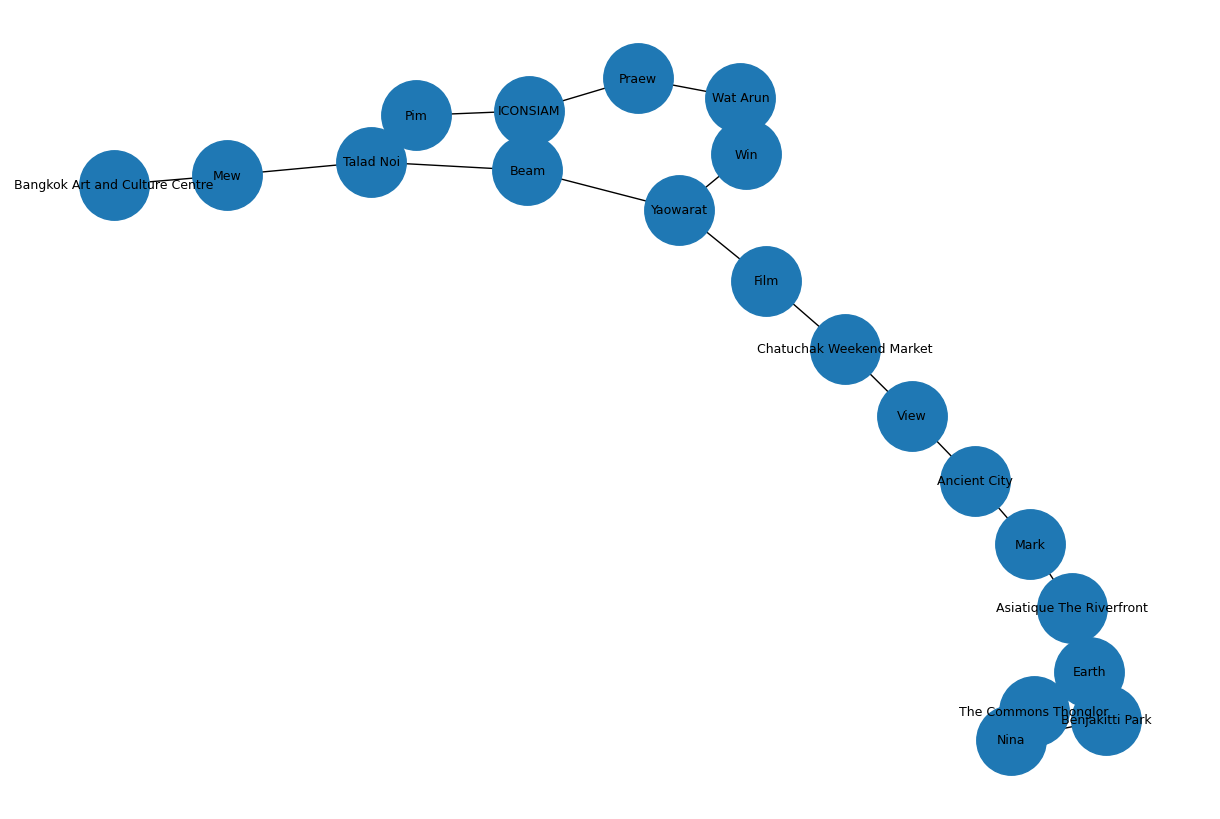

In [53]:
result = driver.execute_query(
    "MATCH (u:User)-[:LIKES]->(l:Location) RETURN u.name AS user, l.name AS location",
    database_=DATABASE
)

G = nx.Graph()
for row in result.records:
    G.add_node(row["user"])
    G.add_node(row["location"])
    G.add_edge(row["user"], row["location"])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, font_size=9)
plt.show()


13. ระบบแนะนำสถานที่ถ่ายรูป



เดินกราฟ User → สถานที่ที่ชอบ → ผู้ใช้อื่น → สถานที่ใหม่ และนับจำนวนเส้นทางเป็นคะแนน


In [59]:
def recommend_locations(target_user, top_n=None):
    if target_user not in users:
        raise ValueError(f"ไม่พบผู้ใช้: {target_user}")

    if top_n is not None and (not isinstance(top_n, int) or top_n <= 0):
        raise ValueError("top_n ต้องเป็นจำนวนเต็มที่มากกว่า 0 หรือเป็น None")

    result = driver.execute_query(
        "MATCH (target:User {name: $target_user})-[:LIKES]->(liked:Location) "
        "MATCH (similar:User)-[:LIKES]->(liked) "
        "WHERE similar <> target "
        "MATCH (similar)-[:LIKES]->(recommended:Location) "
        "WHERE NOT (target)-[:LIKES]->(recommended) "
        "RETURN recommended.name AS location, count(*) AS score "
        "ORDER BY score DESC, location ASC",
        target_user=target_user, database_=DATABASE
    )

    recommendations = [(r["location"], r["score"]) for r in result.records]
    return recommendations[:top_n] if top_n is not None else recommendations


ทดสอบระบบแนะนำ


In [55]:
print("Pim →", recommend_locations("Pim"))
print("Beam →", recommend_locations("Beam"))
print("Mew →", recommend_locations("Mew"))


Pim → [('Yaowarat', 2), ('Bangkok Art and Culture Centre', 1), ('Wat Arun', 1)]
Beam → [('Wat Arun', 2), ('Bangkok Art and Culture Centre', 1), ('Chatuchak Weekend Market', 1)]
Mew → [('ICONSIAM', 2), ('Yaowarat', 1)]


In [56]:
for user in users:
    print(f"{user:5s} → {recommend_locations(user, top_n=3)}")


Pim   → [('Yaowarat', 2), ('Bangkok Art and Culture Centre', 1), ('Wat Arun', 1)]
Beam  → [('Wat Arun', 2), ('Bangkok Art and Culture Centre', 1), ('Chatuchak Weekend Market', 1)]
Mew   → [('ICONSIAM', 2), ('Yaowarat', 1)]
Film  → [('Ancient City', 1), ('ICONSIAM', 1), ('Talad Noi', 1)]
Nina  → [('Asiatique The Riverfront', 2)]
Earth → [('Ancient City', 1)]
Praew → [('Talad Noi', 2), ('Yaowarat', 2)]
Win   → [('ICONSIAM', 2), ('Chatuchak Weekend Market', 1), ('Talad Noi', 1)]
View  → [('Asiatique The Riverfront', 1), ('Yaowarat', 1)]
Mark  → [('Benjakitti Park', 1), ('Chatuchak Weekend Market', 1), ('The Commons Thonglor', 1)]


14. ตรวจสอบจำนวน Node และ Relationship



In [57]:
result = driver.execute_query(
    "MATCH (n) RETURN count(n) AS total_nodes",
    database_=DATABASE
)
print("จำนวน Node ทั้งหมด =", result.records[0]["total_nodes"])

result = driver.execute_query(
    "MATCH ()-[r]->() RETURN count(r) AS total_relationships",
    database_=DATABASE
)
print("จำนวน Relationship ทั้งหมด =", result.records[0]["total_relationships"])


จำนวน Node ทั้งหมด = 20
จำนวน Relationship ทั้งหมด = 34


15. ดูกราฟใน Neo4j Browser



ใช้ Cypher นี้ใน Neo4j Browser:

```cypher
MATCH p = (:User)-[:LIKES]->(:Location)
RETURN p
```


16. ปิดการเชื่อมต่อ



In [58]:
driver.close()
print("ปิดการเชื่อมต่อแล้ว")


ปิดการเชื่อมต่อแล้ว
